# Notebook 09 — Model Comparison & Interpretation (Section 6)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings, pickle
warnings.filterwarnings('ignore')

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score
from sklearn.preprocessing import LabelEncoder

OUTPUTS_DIR = Path("outputs")
MODELS_DIR = Path("models")

print("Libraries loaded.")

Libraries loaded.


## 1. Load All Model Results

In [2]:
result_files = {
    'TF-IDF Classical': OUTPUTS_DIR / 'results_tfidf_classical.csv',
    'NN Embedding': OUTPUTS_DIR / 'results_nn_embed.csv',
    'Pretrained Embed': OUTPUTS_DIR / 'results_pretrained.csv',
    'Advanced (LSTM/CNN/BERT)': OUTPUTS_DIR / 'results_advanced.csv',
    'LLM (Zero-Shot)': OUTPUTS_DIR / 'results_llm.csv',
}

all_results = []
for model_group, path in result_files.items():
    if path.exists():
        df = pd.read_csv(path)
        df['model_group'] = model_group
        all_results.append(df)
    else:
        print(f"Missing: {path}")

if all_results:
    combined = pd.concat(all_results, ignore_index=True)
    print(f"Total result rows: {len(combined)}")
    print(combined.head(10))
else:
    print("No result files found. Run previous notebooks first.")
    combined = pd.DataFrame(columns=['model', 'task', 'accuracy', 'f1_macro', 'model_group'])

Total result rows: 20
          Task               Model  Accuracy  F1-macro       model_group  \
0     category           LinearSVC    0.6065    0.4061  TF-IDF Classical   
1     category  LogisticRegression    0.6341    0.3980  TF-IDF Classical   
2     category        RandomForest    0.6127    0.3401  TF-IDF Classical   
3    sentiment           LinearSVC    0.7949    0.6358  TF-IDF Classical   
4    sentiment  LogisticRegression    0.8088    0.6269  TF-IDF Classical   
5    sentiment        RandomForest    0.7888    0.5649  TF-IDF Classical   
6  star_rating           LinearSVC    0.5061    0.4388  TF-IDF Classical   
7  star_rating  LogisticRegression    0.5296    0.4350  TF-IDF Classical   
8  star_rating        RandomForest    0.5043    0.3441  TF-IDF Classical   
9          NaN                 NaN       NaN       NaN      NN Embedding   

        task  accuracy  f1_macro mode model  
0        NaN       NaN       NaN  NaN   NaN  
1        NaN       NaN       NaN  NaN   NaN  
2  

## 2. Comparison Table

In [3]:
# Pivot table: model vs task
if len(combined) > 0:
    pivot = combined.pivot_table(
        values='f1_macro', index=['model_group', 'model'], columns='task', aggfunc='max'
    ).round(4)
    print("F1-macro by model and task:")
    print(pivot.to_string())
    
    pivot.to_csv(OUTPUTS_DIR / 'model_comparison.csv')
    print("\nSaved to outputs/model_comparison.csv")

F1-macro by model and task:
task                                      category  sentiment
model_group              model                               
Advanced (LSTM/CNN/BERT) BiLSTM                NaN     0.6440
                         DistilBERT            NaN     0.6239
                         TextCNN               NaN     0.6448
LLM (Zero-Shot)          Ollama-LLaMA3.2       NaN     0.5743
                         ZeroShot-BART       0.299     0.5505

Saved to outputs/model_comparison.csv


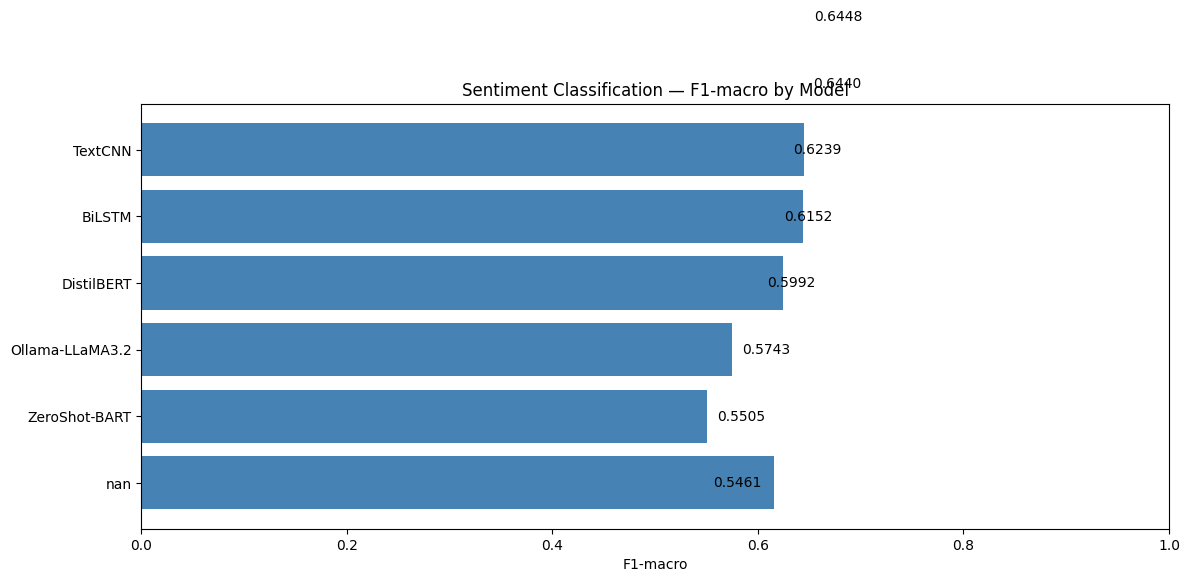

In [5]:
# Bar chart comparison
if len(combined) > 0:
    # Focus on sentiment task
    sent_results = combined[combined['task'] == 'sentiment'].copy()
    sent_results['model'] = sent_results['model'].astype(str)
    if len(sent_results) > 0:
        sent_results = sent_results.sort_values('f1_macro', ascending=True)
        plt.figure(figsize=(12, 6))
        plt.barh(sent_results['model'], sent_results['f1_macro'], color='steelblue')
        plt.xlabel('F1-macro')
        plt.title('Sentiment Classification — F1-macro by Model')
        plt.xlim(0, 1)
        for i, v in enumerate(sent_results['f1_macro']):
            plt.text(v + 0.01, i, f'{v:.4f}', va='center')
        plt.tight_layout()
        plt.savefig(OUTPUTS_DIR / 'model_comparison_sentiment.png', dpi=100)
        plt.show()

## 3. Error Analysis — Load Test Predictions

In [6]:
# Load test data and best model predictions for error analysis
test_df = pd.read_csv(OUTPUTS_DIR / 'test.csv').dropna(subset=['text', 'sentiment'])

# Load TF-IDF + LogReg (most likely trained)
tfidf_path = MODELS_DIR / 'tfidf_sentiment.pkl'
logreg_path = MODELS_DIR / 'tfidf_logreg_sentiment.pkl'

if tfidf_path.exists() and logreg_path.exists():
    with open(tfidf_path, 'rb') as f:
        tfidf = pickle.load(f)
    with open(logreg_path, 'rb') as f:
        logreg = pickle.load(f)
    
    X_test = test_df['text'].fillna('')
    y_true = test_df['sentiment'].astype(str)
    
    X_test_tfidf = tfidf.transform(X_test)
    y_pred = logreg.predict(X_test_tfidf)
    
    test_df = test_df.copy()
    test_df['pred_sentiment'] = y_pred
    test_df['correct'] = (y_true.values == y_pred)
    
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print(classification_report(y_true, y_pred, zero_division=0))
else:
    print("TF-IDF models not found. Run Notebook 04 first.")
    test_df['pred_sentiment'] = None
    test_df['correct'] = None

Accuracy: 0.8088
              precision    recall  f1-score   support

    negative       0.82      0.96      0.88      2198
     neutral       0.41      0.09      0.14       676
    positive       0.82      0.89      0.86      1947

    accuracy                           0.81      4821
   macro avg       0.68      0.65      0.63      4821
weighted avg       0.76      0.81      0.77      4821



## 4. Confusion Matrix Heatmap

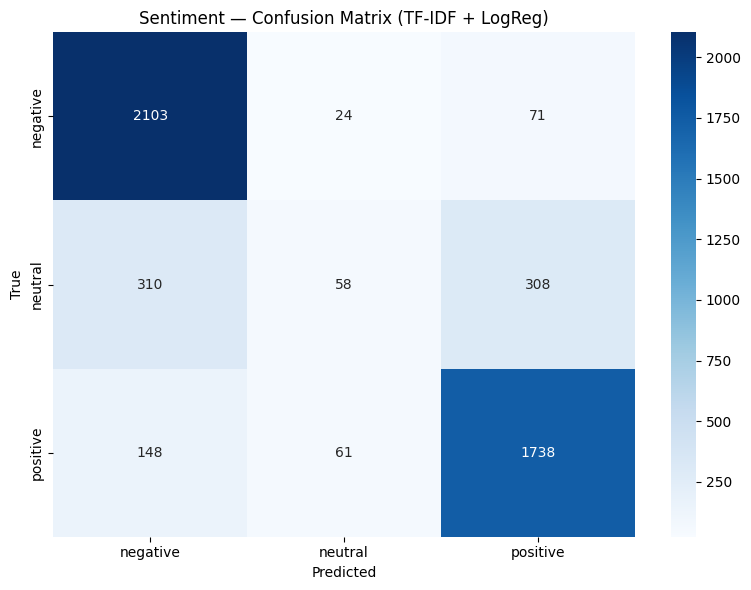

In [7]:
if tfidf_path.exists():
    labels = sorted(y_true.unique())
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
    plt.title('Sentiment — Confusion Matrix (TF-IDF + LogReg)')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.savefig(OUTPUTS_DIR / 'error_analysis_cm.png', dpi=100)
    plt.show()

## 5. Misclassified Examples

In [8]:
if test_df['correct'].notna().any():
    errors = test_df[~test_df['correct']][['text', 'sentiment', 'pred_sentiment']].head(10)
    print("Misclassified examples:\n")
    for _, row in errors.iterrows():
        print(f"True: {row['sentiment']} | Pred: {row['pred_sentiment']}")
        print(f"Text: {str(row['text'])[:120]}")
        print("---")

Misclassified examples:

True: neutral | Pred: negative
Text: I have all my insurance contracts at DA for several years. I never had anything to complain about ... until today. I jus
---
True: neutral | Pred: positive
Text: The prices are advantageous and quote fast, everything is simple. But the PRUX is correct over a year then the insurance
---
True: neutral | Pred: negative
Text: Interlocutor of contemptuous and non -reachable insurance
It is the customer that we must listen to and not be available
---
True: neutral | Pred: positive
Text: Hello I am satisfied with your service at the moment does not change my mind the price and correct the rest I will disco
---
True: negative | Pred: neutral
Text: A little expensive, especially for an old customer.
---
True: neutral | Pred: positive
Text: The service is at the top! The online procedures are simple. In addition, the rates that increase while the penalus decr
---
True: neutral | Pred: negative
Text: I cannot say what and good or not b

## 6. Sentiment Distribution by Insurer & Product

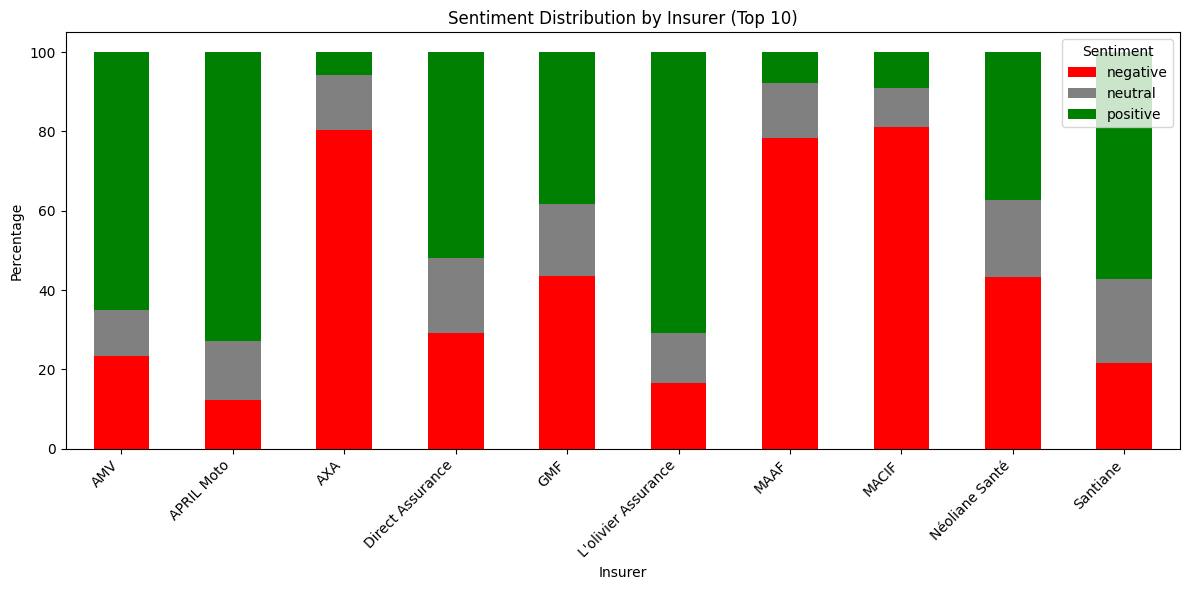

In [9]:
df_all = pd.read_csv(OUTPUTS_DIR / 'reviews_clean.csv')

# By insurer (top 10)
if 'assureur' in df_all.columns and 'sentiment' in df_all.columns:
    top_insurers = df_all['assureur'].value_counts().head(10).index
    df_top = df_all[df_all['assureur'].isin(top_insurers)]
    
    cross_tab = pd.crosstab(df_top['assureur'], df_top['sentiment'], normalize='index') * 100
    
    plt.figure(figsize=(12, 6))
    cross_tab.plot(kind='bar', stacked=True, ax=plt.gca(),
                   color=['red', 'gray', 'green'])
    plt.title('Sentiment Distribution by Insurer (Top 10)')
    plt.xlabel('Insurer')
    plt.ylabel('Percentage')
    plt.legend(title='Sentiment')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(OUTPUTS_DIR / 'sentiment_by_insurer.png', dpi=100)
    plt.show()

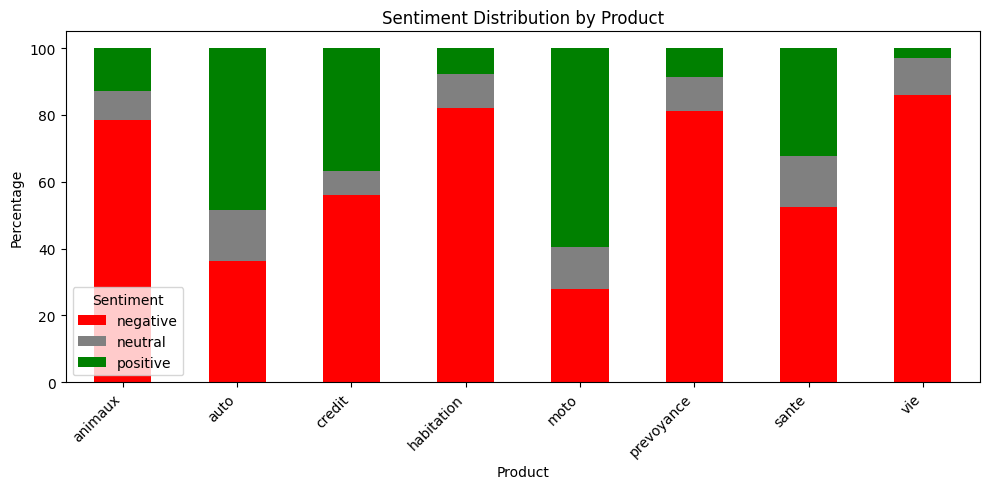

In [10]:
# By product
if 'produit' in df_all.columns and 'sentiment' in df_all.columns:
    top_products = df_all['produit'].value_counts().head(8).index
    df_prod = df_all[df_all['produit'].isin(top_products)]
    
    cross_prod = pd.crosstab(df_prod['produit'], df_prod['sentiment'], normalize='index') * 100
    
    plt.figure(figsize=(10, 5))
    cross_prod.plot(kind='bar', stacked=True, ax=plt.gca(),
                    color=['red', 'gray', 'green'])
    plt.title('Sentiment Distribution by Product')
    plt.xlabel('Product')
    plt.ylabel('Percentage')
    plt.legend(title='Sentiment')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(OUTPUTS_DIR / 'sentiment_by_product.png', dpi=100)
    plt.show()

## 7. Topic × Sentiment Cross-Tabulation

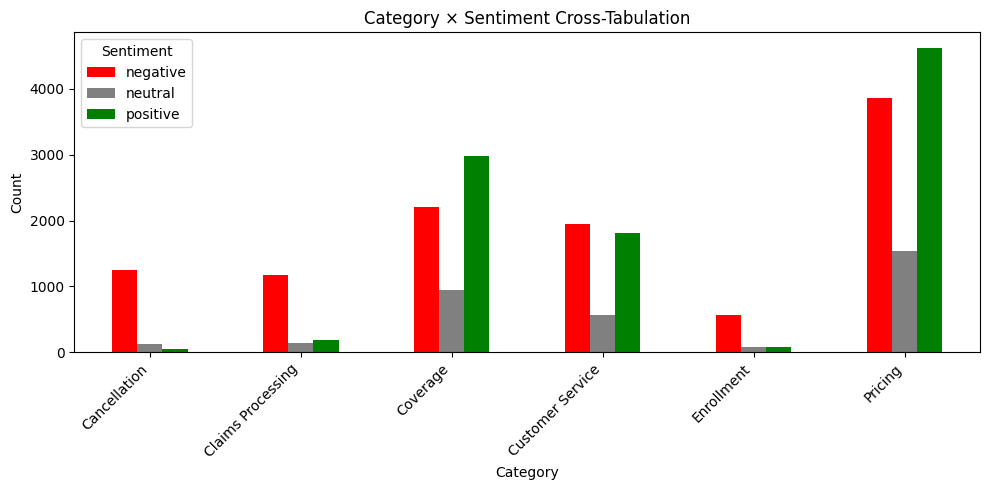

Category × Sentiment (%):
sentiment          negative  neutral  positive
category                                      
Cancellation           87.8      8.5       3.7
Claims Processing      78.3      9.2      12.5
Coverage               35.9     15.4      48.7
Customer Service       45.0     13.2      41.8
Enrollment             78.1     11.1      10.8
Pricing                38.5     15.3      46.2


In [11]:
if 'category' in df_all.columns and 'sentiment' in df_all.columns:
    ct = pd.crosstab(df_all['category'], df_all['sentiment'])
    
    plt.figure(figsize=(10, 5))
    ct.plot(kind='bar', ax=plt.gca(), color=['red', 'gray', 'green'])
    plt.title('Category × Sentiment Cross-Tabulation')
    plt.xlabel('Category')
    plt.ylabel('Count')
    plt.legend(title='Sentiment')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(OUTPUTS_DIR / 'category_sentiment_cross.png', dpi=100)
    plt.show()
    
    # Normalized version
    ct_norm = pd.crosstab(df_all['category'], df_all['sentiment'], normalize='index') * 100
    print("Category × Sentiment (%):")
    print(ct_norm.round(1))

## 8. LIME Explanation for Best Model

In [12]:
from lime.lime_text import LimeTextExplainer

if tfidf_path.exists():
    class_names = sorted(test_df['sentiment'].unique())
    explainer = LimeTextExplainer(class_names=class_names)
    
    def predict_proba(texts):
        X = tfidf.transform(texts)
        return logreg.predict_proba(X)
    
    # Explain a few examples
    for idx in [0, 1, 2]:
        text = test_df['text'].iloc[idx]
        exp = explainer.explain_instance(str(text), predict_proba, num_features=10)
        print(f"\nReview {idx}: {str(text)[:100]}")
        print(f"True: {test_df['sentiment'].iloc[idx]} | Pred: {test_df['pred_sentiment'].iloc[idx]}")
        print("LIME explanation (word → weight):")
        for feat, weight in exp.as_list():
            print(f"  {feat:<20} {weight:+.4f}")
    
    # Save HTML explanation for first example
    exp.save_to_file(str(OUTPUTS_DIR / 'lime_explanation.html'))
    print("\nSaved lime_explanation.html")
else:
    print("Models not found.")


Review 0: I am very satisfied with this insurance, I have been affiliated there for 3 years. I had sinister an
True: positive | Pred: positive
LIME explanation (word → weight):
  very                 -0.0221
  perfect              -0.0199
  satisfied            -0.0160
  recommend            -0.0154
  everything           -0.0093
  unbeatable           -0.0083
  professional         -0.0079
  for                  -0.0077
  this                 +0.0067
  highly               -0.0064

Review 1: I will tell you a very very funny story and enormous proof of incompetence on the part of this insur
True: negative | Pred: negative
LIME explanation (word → weight):
  refuse               -0.0261
  change               -0.0241
  person               +0.0237
  knew                 +0.0220
  Thank                +0.0219
  car                  -0.0190
  incompetence         -0.0189
  they                 -0.0178
  very                 +0.0150
  sure                 -0.0136

Review 2: We have been 

## Summary
- Aggregated all model results into comparison table
- Error analysis on TF-IDF + LogReg (best available classical model)
- Sentiment distribution by insurer and product
- Category × sentiment cross-tabulation
- LIME word-level explanation for misclassified examples